<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/HR_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

# 1️⃣ --- Cek apakah GPU aktif di Colab ---
import os
gpu_info = os.popen('nvidia-smi').read()
if "failed" in gpu_info:
    print("⚠️ GPU belum aktif. Aktifkan via Runtime > Change runtime type > GPU")
else:
    print("✅ GPU aktif dan siap dipakai!")
    print(gpu_info.split('\n')[0])

# 2️⃣ --- Cara 1: Pakai %%time (khusus untuk cell di Colab) ---
# Jalankan ini di satu cell Colab terpisah:
# %%time
# for i in range(10_000_000):
#     _ = i ** 2

# 3️⃣ --- Cara 2: Pakai time.time() manual ---
import time

print("\n⏱️ Mengukur waktu dengan time.time() ...")
start = time.time()
for i in range(10_000_000):
    _ = i ** 2
end = time.time()
print(f"Waktu eksekusi loop biasa: {end - start:.3f} detik")

# 4️⃣ --- Cara 3: Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()  # pertama kali akan kompilasi (lebih lambat)
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()  # eksekusi berikutnya super cepat
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")

# 5️⃣ --- Cara 4: Gunakan operasi vectorized (NumPy) ---
import numpy as np

print("\n⚙️ Mengukur waktu dengan operasi vectorized NumPy ...")
start = time.time()
x = np.arange(10_000_000)
y = x ** 2  # super cepat tanpa loop manual
end = time.time()
print(f"Waktu eksekusi NumPy: {end - start:.3f} detik")

# 6️⃣ --- Bonus: Decorator otomatis untuk mengukur waktu fungsi ---
def timed(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"⏰ Fungsi '{func.__name__}' selesai dalam {end - start:.3f} detik")
        return result
    return wrapper

@timed
def contoh_fungsi():
    s = 0
    for i in range(5_000_000):
        s += i ** 2
    return s

print("\n🧩 Contoh fungsi dengan decorator otomatis:")
contoh_fungsi()

✅ GPU aktif dan siap dipakai!


⏱️ Mengukur waktu dengan time.time() ...
Waktu eksekusi loop biasa: 1.224 detik

⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 0.067 detik
Eksekusi berikutnya: 0.000 detik

⚙️ Mengukur waktu dengan operasi vectorized NumPy ...
Waktu eksekusi NumPy: 0.097 detik

🧩 Contoh fungsi dengan decorator otomatis:
⏰ Fungsi 'contoh_fungsi' selesai dalam 0.521 detik


41666654166667500000

**Import Library**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

**Load Dataset**

In [ ]:
data = pd.read_csv("/content/HR_comma_sep.csv")
print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nChecking for missing values:")
print(data.isnull().sum())

print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())

print("\nPreview data after initial loading and duplicate handling:")
display(data.head())

Preview data:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None

Checking for missing values:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident         

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


**Exploratory Data Analysis (EDA)**

In [ ]:
# Buat salinan data dan lakukan one-hot encoding untuk perhitungan korelasi
data_for_corr = data.copy()
data_for_corr = pd.get_dummies(data_for_corr, columns=['Department', 'salary'], drop_first=True)

print("\nPreview data setelah one-hot encoding (data_for_corr):")
display(data_for_corr.head())


Preview data setelah one-hot encoding (data_for_corr):


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


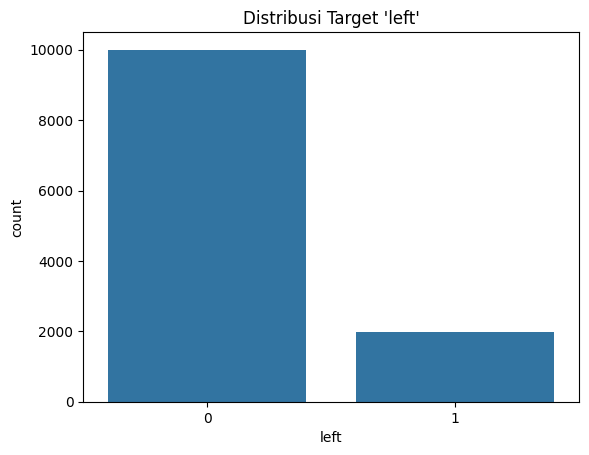

In [ ]:
# Distribusi target
sns.countplot(x='left', data=data)
plt.title("Distribusi Target 'left'")
plt.show() # Tampilkan plot pertama

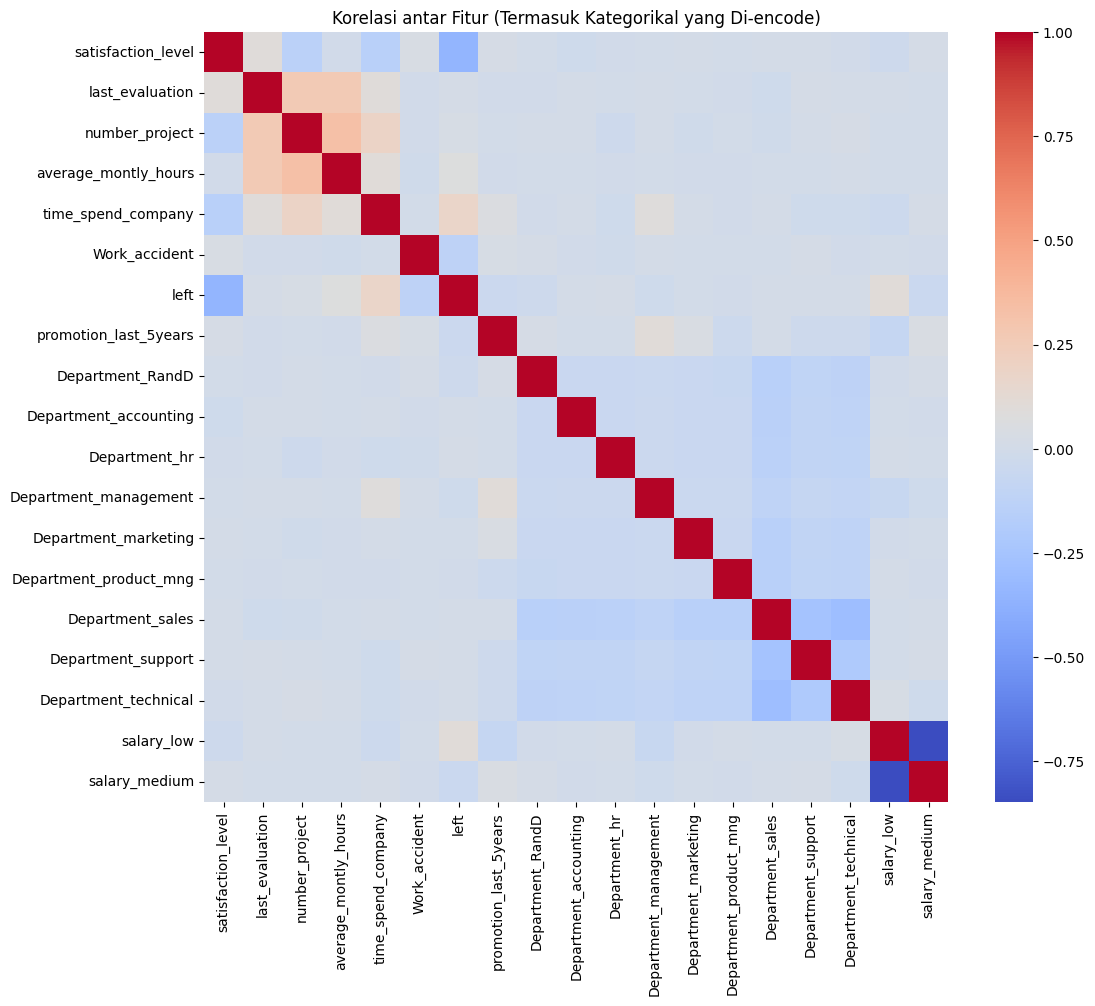

In [ ]:
# Korelasi semua fitur numerik (termasuk yang telah di-encode)
plt.figure(figsize=(12, 10)) # Sesuaikan ukuran figure agar lebih mudah dibaca
sns.heatmap(data_for_corr.corr(), annot=False, cmap='coolwarm') # Ubah annot menjadi False untuk banyak fitur
plt.title("Korelasi antar Fitur (Termasuk Kategorikal yang Di-encode)")
plt.show()

**Split Data**

In [ ]:
y = data['left']
X = data.drop('left', axis=1)

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True) # drop_first=True to avoid multicollinearity

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nX_train (5 baris pertama):")
print(X_train[:5])
print("\nX_test (5 baris pertama):")
print(X_test[:5])
print("\ny_train (5 elemen pertama):")
print(y_train[:5])
print("\ny_test (5 elemen pertama):")
print(y_test[:5])


X_train (5 baris pertama):
       satisfaction_level  last_evaluation  number_project  \
2041                 0.98             0.91               4   
10444                0.63             0.89               3   
2030                 0.85             0.59               3   
11606                0.56             0.39               3   
2008                 0.50             0.75               6   

       average_montly_hours  time_spend_company  Work_accident  \
2041                    240                   3              0   
10444                   239                   3              0   
2030                    235                   3              0   
11606                   106                   8              0   
2008                    127                   3              0   

       promotion_last_5years  Department_RandD  Department_accounting  \
2041                       0             False                  False   
10444                      0             False          

**Standardisasi**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Encoding Kolom Kategorikal**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 5️⃣ Tentukan Kolom Kategori dan Numerik (sesuai dataset HR_comma_sep.csv)
categorical_cols = ['Department', 'salary']
numeric_cols = [
    'satisfaction_level', 'last_evaluation', 'number_project',
    'average_montly_hours', 'time_spend_company', 'Work_accident',
    'promotion_last_5years'
]

# 6️⃣ Buat Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

**Latih Model**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean')

**Model Awal (Tanpa Tuning)**

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print("Akurasi Awal:", accuracy_score(y_test, y_pred))

Akurasi Awal: 0.9508128386827845


**Hyperparameter Tuning dengan Grid Search**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, return_train_score=True)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score (CV):", grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best Score (CV): 0.9511057038418841


**Evaluasi Model**

Accuracy: 0.9508128386827845

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      2001
           1       0.83      0.89      0.86       398

    accuracy                           0.95      2399
   macro avg       0.90      0.93      0.91      2399
weighted avg       0.95      0.95      0.95      2399



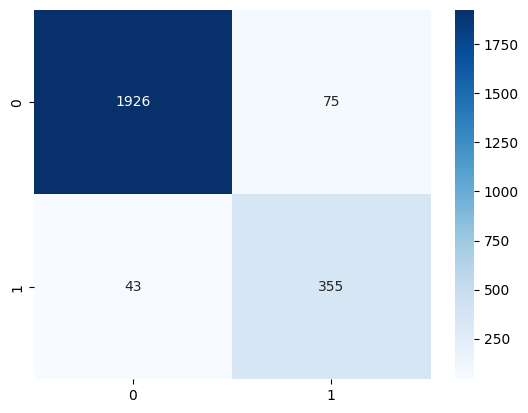

In [ ]:
y_pred = knn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

**Mencari K Terbaik**

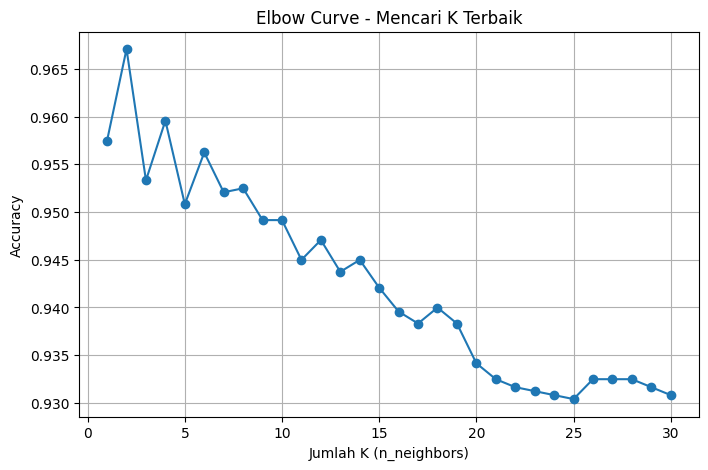

K terbaik = 2

Nilai Akurasi untuk Setiap K:
K = 1: Akurasi = 0.9575
K = 2: Akurasi = 0.9671
K = 3: Akurasi = 0.9533
K = 4: Akurasi = 0.9596
K = 5: Akurasi = 0.9508
K = 6: Akurasi = 0.9562
K = 7: Akurasi = 0.9521
K = 8: Akurasi = 0.9525
K = 9: Akurasi = 0.9491
K = 10: Akurasi = 0.9491
K = 11: Akurasi = 0.9450
K = 12: Akurasi = 0.9471
K = 13: Akurasi = 0.9437
K = 14: Akurasi = 0.9450
K = 15: Akurasi = 0.9421
K = 16: Akurasi = 0.9396
K = 17: Akurasi = 0.9383
K = 18: Akurasi = 0.9400
K = 19: Akurasi = 0.9383
K = 20: Akurasi = 0.9341
K = 21: Akurasi = 0.9325
K = 22: Akurasi = 0.9316
K = 23: Akurasi = 0.9312
K = 24: Akurasi = 0.9308
K = 25: Akurasi = 0.9304
K = 26: Akurasi = 0.9325
K = 27: Akurasi = 0.9325
K = 28: Akurasi = 0.9325
K = 29: Akurasi = 0.9316
K = 30: Akurasi = 0.9308


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 31)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train) # Menggunakan X_train_scaled dan y_train
    y_pred = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(k_values, scores, marker='o')
plt.xlabel("Jumlah K (n_neighbors)")
plt.ylabel("Accuracy")
plt.title("Elbow Curve - Mencari K Terbaik")
plt.grid(True)
plt.show()

best_k = k_values[scores.index(max(scores))]
print("K terbaik =", best_k)

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred_knn = knn_final.predict(X_test_scaled)

print("\nNilai Akurasi untuk Setiap K:")
for k, score in zip(k_values, scores):
    print(f"K = {k}: Akurasi = {score:.4f}")

**Confusion Matrix**

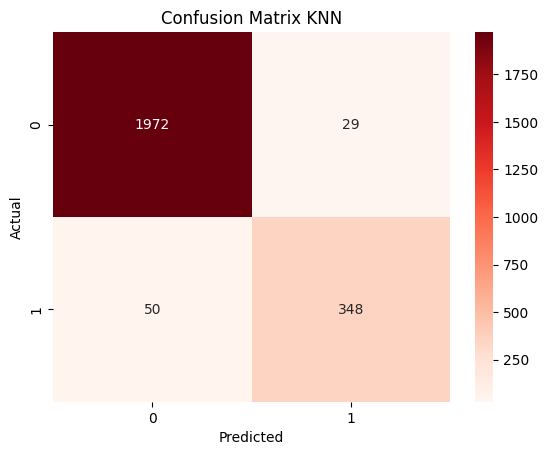

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap="Reds")
plt.title("Confusion Matrix KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC CURVE**

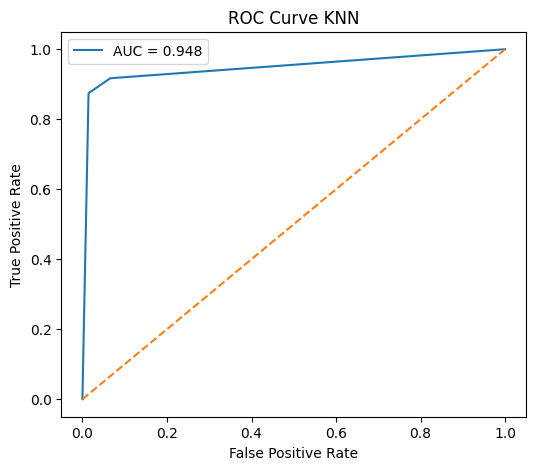

In [ ]:
# ROC CURVE
y_proba = knn_final.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve KNN")
plt.legend()
plt.show()

**Analisis Parameter Paling Berpengaruh terhadap Akurasi**

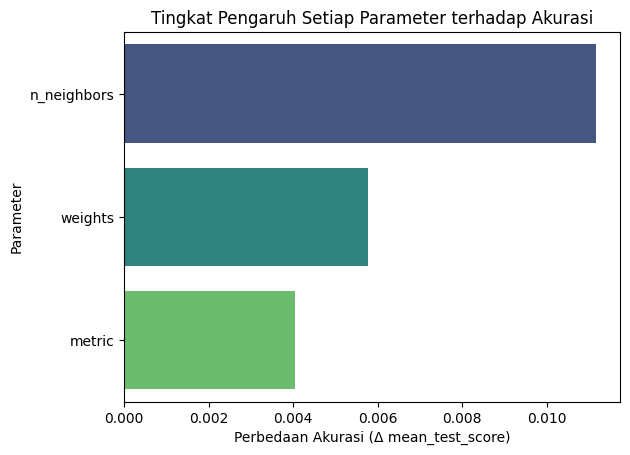

     Parameter  Pengaruh (Δ Akurasi)
0  n_neighbors              0.011181
1      weights              0.005778
2       metric              0.004051


In [ ]:
influence = []

for param in ['param_n_neighbors', 'param_weights', 'param_metric']:
    # Access results from grid_search.cv_results_
    df_results = pd.DataFrame(grid_search.cv_results_)
    impact = df_results.groupby(param)['mean_test_score'].mean().max() - df_results.groupby(param)['mean_test_score'].mean().min()
    influence.append({'Parameter': param.replace('param_', ''), 'Pengaruh (Δ Akurasi)': impact})

df_influence = pd.DataFrame(influence).sort_values(by='Pengaruh (Δ Akurasi)', ascending=False)

sns.barplot(x='Pengaruh (Δ Akurasi)', y='Parameter', hue='Parameter', data=df_influence, palette="viridis", legend=False)
plt.title("Tingkat Pengaruh Setiap Parameter terhadap Akurasi")
plt.xlabel("Perbedaan Akurasi (Δ mean_test_score)")
plt.ylabel("Parameter")
plt.show()

print(df_influence)

**Distribusi Target Attrition**

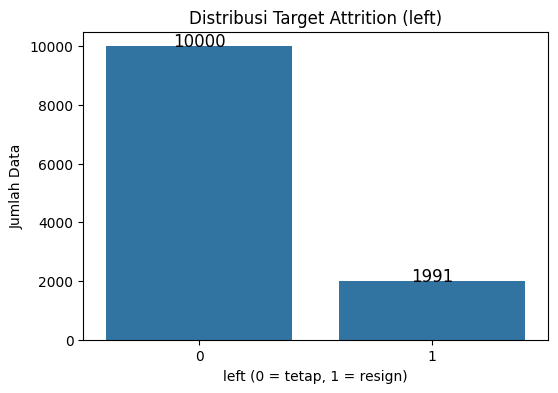

In [ ]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=y)
plt.title("Distribusi Target Attrition (left)")
plt.xlabel("left (0 = tetap, 1 = resign)")
plt.ylabel("Jumlah Data")

# Tambahkan angka di atas bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 2,
        f'{int(height)}',
        ha="center",
        fontsize=12,
        color="black"
    )

plt.show()

**FItur VS Left**

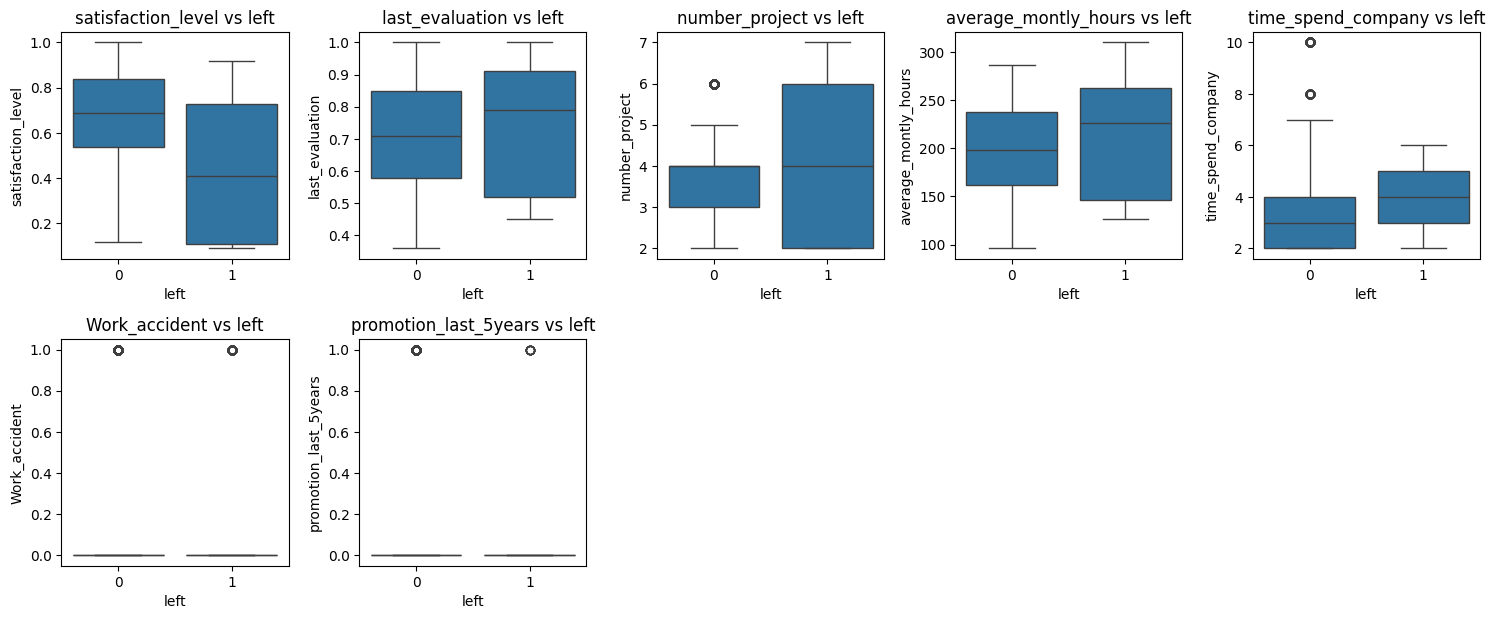

In [ ]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('left')

plt.figure(figsize=(15,12))

for idx, col in enumerate(num_cols, 1):
    plt.subplot(4,5,idx)
    sns.boxplot(x=data['left'], y=data[col])
    plt.title(f"{col} vs left")
    plt.tight_layout()

**Korelasi dengan target (left)**

Top 5 Fitur Paling Berpengaruh Terhadap Attrition (left):


,feature,correlation_with_left
0,satisfaction_level,-0.350558
1,time_spend_company,0.173295
2,Work_accident,-0.125436
3,salary_low,0.099113
4,average_montly_hours,0.070409


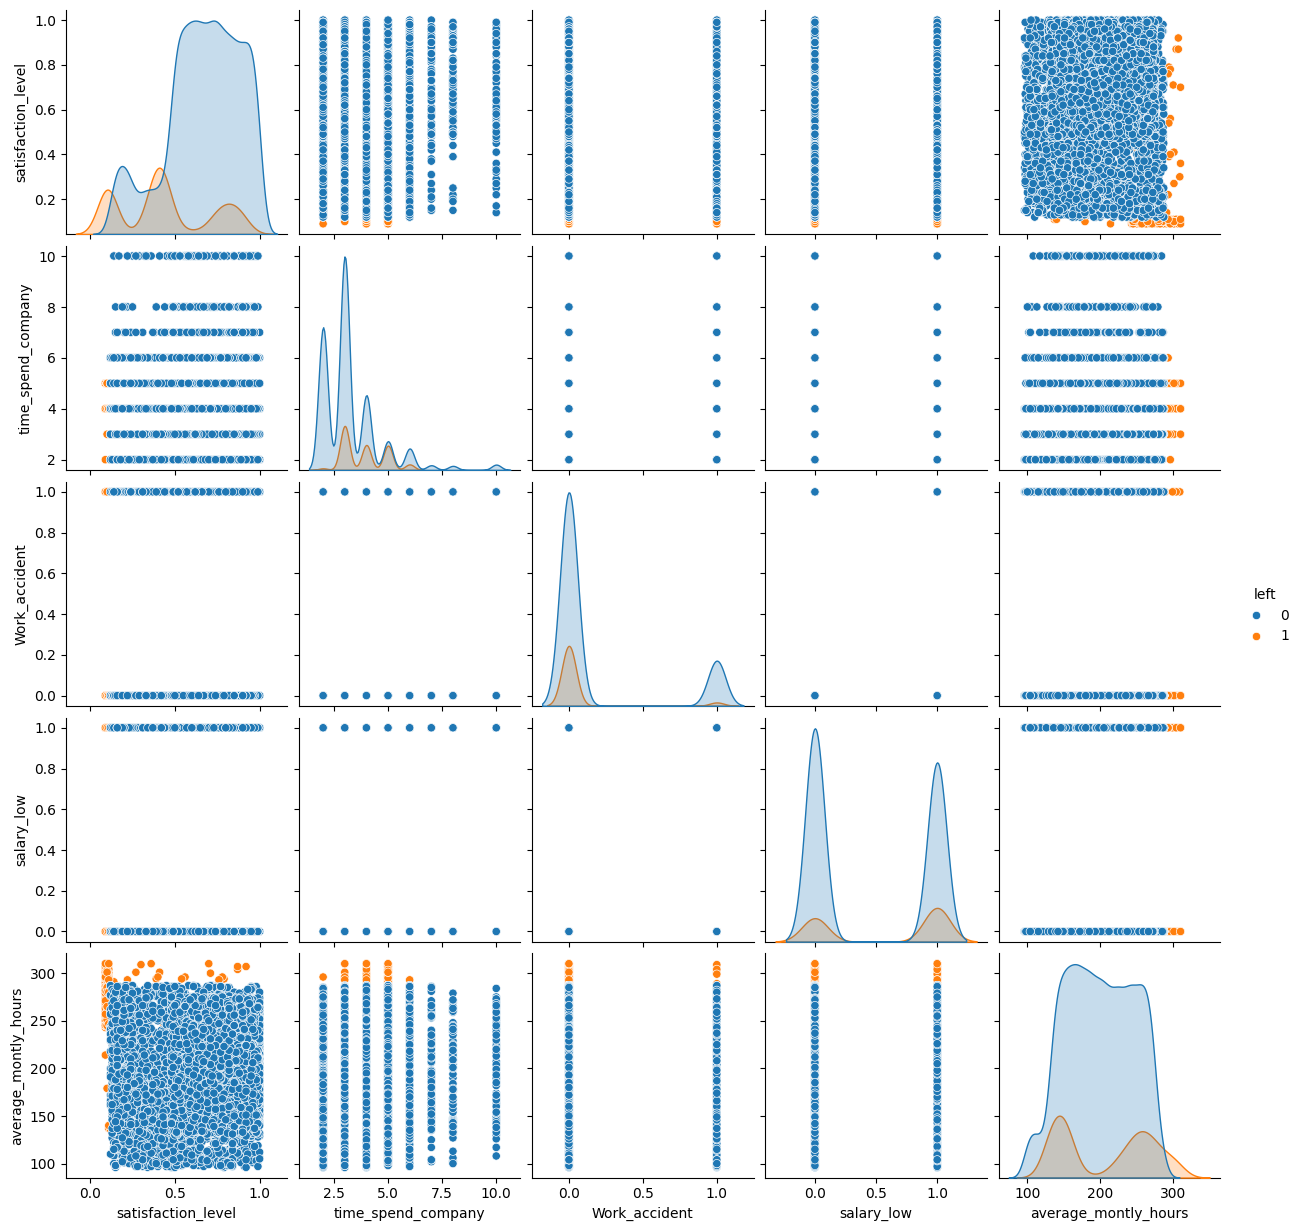

In [ ]:
# Hitung korelasi dengan target (left)
corr_target = data_for_corr.corr()['left'].drop('left')

# Ambil 5 fitur dengan korelasi absolut terbaik
top5_corr = corr_target.abs().sort_values(ascending=False).head(5)
top5_features = top5_corr.index.tolist()

# Tabel ringkas
top5_table = pd.DataFrame({
    'feature': top5_features,
    'correlation_with_left': corr_target[top5_features].values
})

print("Top 5 Fitur Paling Berpengaruh Terhadap Attrition (left):")
display(top5_table)

# Pairplot dengan data_for_corr (agar kolom cocok)
sns.pairplot(data_for_corr[top5_features + ['left']], hue='left')
plt.show()